# 260527 — Atomblob-ViT-MAE inspection

Companion to `260523_density_vit_mae_inspect.ipynb`. Here the pretext is **atom-blob MAE**: the encoder ingests the raw 11-channel atom voxels (7 ligand + 4 pocket), 60% of the 8³ blocks are zero-masked, and the model reconstructs the masked atom voxels.

No density is built or loaded in this variant (`use_xray=false`, `input_mode='atomblob'`). The 11-channel auxiliary structure head is also disabled (`n_struct_channels=0`) because the atom channels *are* the input — the structure-head task is redundant.

Plots:
1. **Per-source sums** — ligand-sum (7-ch) and pocket-sum (4-ch) for ground truth | masked input | predicted | error, x/y/z planes.
2. **Per-channel** — all 11 channels (target / predicted / abs error) on a single slice axis.
3. **Quantitative split** — per-source MSE on atoms-present vs background voxels, masked vs visible.

**Relation to the VoxBind dataset.** The atomblob input is *exactly* the same 11-channel atom voxel tensor (`v_lig` 7ch + `v_poc` 4ch) that the VoxBind pipeline already produces — channels are NOT collapsed to one. The only differences from the density-MAE variant are:
- no Gaussian blur (density step is skipped),
- no additive noise (`sigma_noise = 0.0`),
- the patch-embed input width is 11 instead of 1.

In [1]:
# ── imports + paths ─────────────────────────────────────────────
import sys, os
VOX_ROOT = '/home/shpark/prj-denovo/VoxBind'
if VOX_ROOT not in sys.path:
    sys.path.insert(0, VOX_ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

from voxbind.models.density_vit import DensityViTMAE
from voxbind.models.density_mae import make_block_mask
from voxbind.dataset.crossdocked import DatasetCrossdocked
from voxbind.voxelizer import Voxelizer
from voxbind.constants import ELEMENTS_HASH_CROSSDOCKED

device = torch.device('cuda:5' if torch.cuda.is_available() else 'cpu')
torch.set_grad_enabled(False)
print('device:', device)

device: cuda:5


In [2]:
# ── knobs ───────────────────────────────────────────────────────
EXP_DIR = f'{VOX_ROOT}/voxbind/exps/260526_atomblob_vit_mae_40m_pretrain'
CKPT_PATH = f'{EXP_DIR}/checkpoint.pth.tar'    # or checkpoint_e0020.pth.tar / e0040 / …
DATA_DIR = f'{VOX_ROOT}/voxbind/dataset/data'

SAMPLE_IDX = 7        # which val sample to visualize (0..99); matches the density notebooks
SLICE_AXIS = 'z'      # 'x', 'y', or 'z' — for the per-channel grid
SLICE_OFFSET = 0      # offset from grid center (in voxels)
SEED_MASK = 0         # reproducible block mask  (same as density-MAE inspect for direct comparison)

# Match the training config (configs/config_train_atomblob_vit_mae_40m.yaml > mae)
BLOCK_SIZE = 8
MASK_RATIO = 0.60
RESOLUTION = 0.25     # Å / voxel
GRID_DIM = 64
STRUCT_POS_THRESH = 0.05
print(f'mask: {MASK_RATIO:.2f} of {BLOCK_SIZE}³-voxel blocks zeroed; input is 11-ch atom voxels')

mask: 0.60 of 8³-voxel blocks zeroed; input is 11-ch atom voxels


In [3]:
# ── load model from checkpoint ─────────────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
cfg = ckpt['cfg'] if 'cfg' in ckpt else None
print('ckpt epoch:', ckpt.get('epoch'), '| global_step:', ckpt.get('global_step'))
if cfg is not None:
    print('model cfg:', OmegaConf.to_container(cfg.model, resolve=True))
    print('input_mode:', cfg.get('input_mode'))

model = DensityViTMAE(
    grid_dim=int(cfg.vox.grid_dim) if cfg is not None else GRID_DIM,
    patch_size=int(cfg.model.patch_size) if cfg is not None else 8,
    n_in_channels=int(cfg.model.n_in_channels) if cfg is not None else 11,
    n_channels=int(cfg.model.n_channels) if cfg is not None else 32,
    dim=int(cfg.model.dim) if cfg is not None else 512,
    depth=int(cfg.model.depth) if cfg is not None else 12,
    n_heads=int(cfg.model.heads) if cfg is not None else 8,
    mlp_ratio=int(cfg.model.mlp_ratio) if cfg is not None else 4,
    dropout=float(cfg.model.dropout) if cfg is not None else 0.1,
    n_struct_channels=int(cfg.model.n_struct_channels) if cfg is not None else 0,
).to(device).eval()

sd = ckpt.get('state_dict_ema', ckpt.get('state_dict'))
sd = {k.replace('module.', '').replace('_orig_mod.', ''): v for k, v in sd.items()}
missing, unexpected = model.load_state_dict(sd, strict=False)
print('missing keys:', len(missing), '| unexpected keys:', len(unexpected))
print(f'params: {sum(p.numel() for p in model.parameters()) / 1e6:.3f}M')
print(f'token grid: {model.encoder.g_p}³ = {model.encoder.n_tokens} tokens; patch_size={model.encoder.patch_size}; in_channels={model.encoder.n_in_channels}')

ckpt epoch: 99 | global_step: 98000
model cfg: {'model_name': 'atomblob_vit_mae_40m', 'n_channels': 32, 'patch_size': 8, 'n_in_channels': 11, 'dim': 512, 'depth': 12, 'heads': 8, 'mlp_ratio': 4, 'dropout': 0.1, 'n_struct_channels': 0}
input_mode: atomblob


missing keys: 0 | unexpected keys: 0
params: 45.190M
token grid: 8³ = 512 tokens; patch_size=8; in_channels=11


In [4]:
# ── load + voxelize one val sample ─────────────────────────────────
dset_val = DatasetCrossdocked(
    data_dir=DATA_DIR, split='val', aug=False, small=False,
    ligand_radius=0.5, pocket_radius=-1,
)
print('val set size:', len(dset_val))
sample = dset_val[SAMPLE_IDX]
print('sample id:', sample['ligand']['id'], '|', sample['pocket']['id'])

voxelizer = Voxelizer(
    grid_dim=GRID_DIM, resolution=RESOLUTION, cubes_around=8, device=device,
)
lig = {k: sample['ligand'][k].unsqueeze(0).to(device)
       for k in ('coords', 'radius', 'atoms_channel')}
poc = {k: sample['pocket'][k].unsqueeze(0).to(device)
       for k in ('coords', 'radius', 'atoms_channel')}
v_lig = voxelizer(lig, num_channels=7)      # (1, 7, G, G, G)
v_poc = voxelizer(poc, num_channels=4)      # (1, 4, G, G, G)
print('v_lig:', tuple(v_lig.shape), 'v_poc:', tuple(v_poc.shape))

val set size: 100
sample id: BRD9_HUMAN_133_241_0/4yyg_A_rec_4nqn_y1z_lig_tt_docked_1.sdf | BRD9_HUMAN_133_241_0/4yyg_A_rec_4nqn_y1z_lig_tt_docked_1_pocket10.pdb


v_lig: (1, 7, 64, 64, 64) v_poc: (1, 4, 64, 64, 64)


In [5]:
# ── assemble atomblob input + block mask (mirrors MAEPrefetcher with input_mode='atomblob') ──
x_clean = torch.cat([v_lig, v_poc], dim=1)         # (1, 11, G, G, G) — same as VoxBind atom voxels
print('x_clean:', tuple(x_clean.shape))

g_mask = torch.Generator(device=device).manual_seed(SEED_MASK)
# Reproduce make_block_mask with our own generator for exact mask reproducibility.
B, G = x_clean.shape[0], x_clean.shape[-1]
blocks = torch.rand(B, 1, G // BLOCK_SIZE, G // BLOCK_SIZE, G // BLOCK_SIZE,
                    device=device, generator=g_mask) < MASK_RATIO
mask = blocks.repeat_interleave(BLOCK_SIZE, 2)\
             .repeat_interleave(BLOCK_SIZE, 3)\
             .repeat_interleave(BLOCK_SIZE, 4)
# atomblob has no additive noise (sigma_noise=0.0), so x_noisy = x_clean exactly
x_in = x_clean * (~mask).to(x_clean.dtype)         # broadcasts across all 11 channels

print(f'mask fraction (voxel): {mask.float().mean().item():.3f}  (target {MASK_RATIO})')
n_blocks = (G // BLOCK_SIZE) ** 3
n_blocks_masked = blocks.sum().item()
print(f'masked blocks: {n_blocks_masked}/{n_blocks}')
print(f'x_clean stats: min={x_clean.min().item():.3f}  max={x_clean.max().item():.3f}  '
      f'pos-frac (>{STRUCT_POS_THRESH})={(x_clean > STRUCT_POS_THRESH).float().mean().item():.4f}')

x_clean: (1, 11, 64, 64, 64)
mask fraction (voxel): 0.580  (target 0.6)
masked blocks: 297/512
x_clean stats: min=0.000  max=1.000  pos-frac (>0.05)=0.0778


In [6]:
# ── forward through the model ───────────────────────────────────────
out_pretext, a_hat = model(x_in)
print('out_pretext:', tuple(out_pretext.shape), '   (B, 11, G, G, G) — reconstructed atom voxels')
print('a_hat       :', None if a_hat is None else tuple(a_hat.shape),
      '   (None because n_struct_channels=0)')

# Masked-voxel reconstruction loss, atom channels.
m = mask.to(out_pretext.dtype)
n_masked_spatial = m.sum().clamp(min=1.0)
diff_sq = (out_pretext - x_clean) ** 2 * m         # broadcast (B,1,G,G,G) over 11 channels
L_recon = diff_sq.sum() / (n_masked_spatial * out_pretext.shape[1])
print(f'sample L_recon (masked only, mean over 11 ch): {L_recon.item():.5f}')

# Per-source split (ligand 0:7, pocket 7:11) on atoms-present vs background voxels.
print(f'\nper-source split (threshold {STRUCT_POS_THRESH}):')
for name, tgt, pred in [
    ('lig', x_clean[0, :7],  out_pretext[0, :7]),
    ('poc', x_clean[0, 7:],  out_pretext[0, 7:]),
]:
    pos = tgt > STRUCT_POS_THRESH
    pos_frac = pos.float().mean().item()
    mse_on  = ((pred[pos]  - tgt[pos])  ** 2).mean().item() if pos.any() else float('nan')
    mse_off = ((pred[~pos] - tgt[~pos]) ** 2).mean().item()
    print(
        f'  {name}: pos-frac={pos_frac:.4f}  '
        f'peak tgt={tgt.max().item():.3f} pred={pred.max().item():.3f}  '
        f'MSE@on={mse_on:.4f}  MSE@off={mse_off:.6f}'
    )

# Same split but restricted to masked positions only (i.e. what the loss actually sees).
print(f'\nmasked-only split:')
m_bool = mask[0, 0].bool()
for name, tgt, pred in [
    ('lig', x_clean[0, :7],  out_pretext[0, :7]),
    ('poc', x_clean[0, 7:],  out_pretext[0, 7:]),
]:
    # apply mask along spatial dims (broadcasts across channel dim)
    tgt_m, pred_m = tgt[:, m_bool], pred[:, m_bool]
    pos = tgt_m > STRUCT_POS_THRESH
    mse_on  = ((pred_m[pos]  - tgt_m[pos])  ** 2).mean().item() if pos.any() else float('nan')
    mse_off = ((pred_m[~pos] - tgt_m[~pos]) ** 2).mean().item()
    print(f'  {name}: masked-on={mse_on:.4f}  masked-off={mse_off:.6f}')

out_pretext: (1, 11, 64, 64, 64)    (B, 11, G, G, G) — reconstructed atom voxels
a_hat       : None    (None because n_struct_channels=0)
sample L_recon (masked only, mean over 11 ch): 0.00017

per-source split (threshold 0.05):
  lig: pos-frac=0.0028  peak tgt=0.992 pred=1.027  MSE@on=0.0156  MSE@off=0.000005
  poc: pos-frac=0.2091  peak tgt=1.000 pred=1.033  MSE@on=0.0010  MSE@off=0.000043

masked-only split:
  lig: masked-on=0.0222  masked-off=0.000007
  poc: masked-on=0.0015  masked-off=0.000052


In [7]:
# ── slicing helpers ─────────────────────────────────────────────────
def take_slice(vol, axis='z', offset=0):
    arr = vol.detach().cpu().numpy() if torch.is_tensor(vol) else vol
    G = arr.shape[-1]
    idx = G // 2 + offset
    if axis == 'x':
        return arr[idx, :, :]
    elif axis == 'y':
        return arr[:, idx, :]
    elif axis == 'z':
        return arr[:, :, idx]
    raise ValueError(axis)

def show(ax, img, title, cmap='gray', vmin=None, vmax=None):
    im = ax.imshow(img.T, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    return im

## Plot 1 — ligand-sum and pocket-sum across x/y/z planes

Columns: ground truth | masked input | predicted | error (pred−GT, masked positions only).
Each row is one slice axis. Channel sums over the 7 ligand channels and 4 pocket channels are visualized for compactness; the per-channel breakdown is in Plot 2.

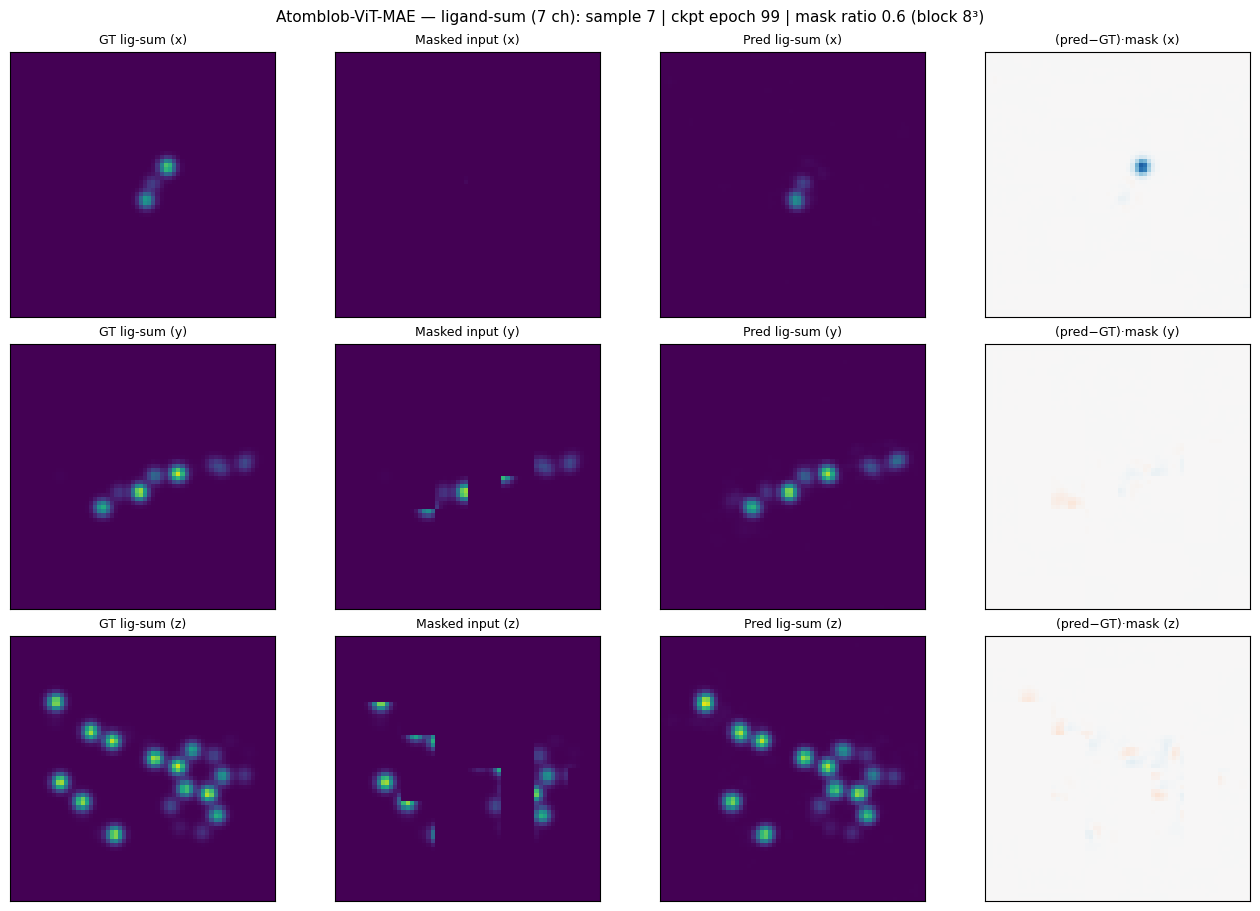

In [8]:
# ── plot 1a: ligand-sum (7 ch) GT | masked | pred | error, for x/y/z planes ───────────
mask_3d = mask[0, 0]
tgt_lig    = x_clean[0, :7].sum(0)
in_lig     = x_in[0, :7].sum(0)
pred_lig   = out_pretext[0, :7].sum(0)
err_lig    = (out_pretext[0, :7] - x_clean[0, :7]).sum(0) * mask_3d.float()

vmax_lig = max(tgt_lig.max().item(), pred_lig.max().item(), 1e-3)
err_abs_lig = max(err_lig.abs().max().item(), 1e-3)

fig, axes = plt.subplots(3, 4, figsize=(13, 9), constrained_layout=True)
for i, ax_name in enumerate(['x', 'y', 'z']):
    show(axes[i, 0], take_slice(tgt_lig, ax_name, SLICE_OFFSET),
         f'GT lig-sum ({ax_name})',     cmap='viridis', vmin=0,            vmax=vmax_lig)
    show(axes[i, 1], take_slice(in_lig, ax_name, SLICE_OFFSET),
         f'Masked input ({ax_name})',  cmap='viridis', vmin=0,            vmax=vmax_lig)
    show(axes[i, 2], take_slice(pred_lig, ax_name, SLICE_OFFSET),
         f'Pred lig-sum ({ax_name})',  cmap='viridis', vmin=0,            vmax=vmax_lig)
    show(axes[i, 3], take_slice(err_lig, ax_name, SLICE_OFFSET),
         f'(pred−GT)·mask ({ax_name})', cmap='RdBu_r', vmin=-err_abs_lig, vmax=err_abs_lig)
fig.suptitle(
    f"Atomblob-ViT-MAE — ligand-sum (7 ch): sample {SAMPLE_IDX} | ckpt epoch {ckpt.get('epoch')} | "
    f"mask ratio {MASK_RATIO} (block {BLOCK_SIZE}³)",
    fontsize=11,
)
plt.show()

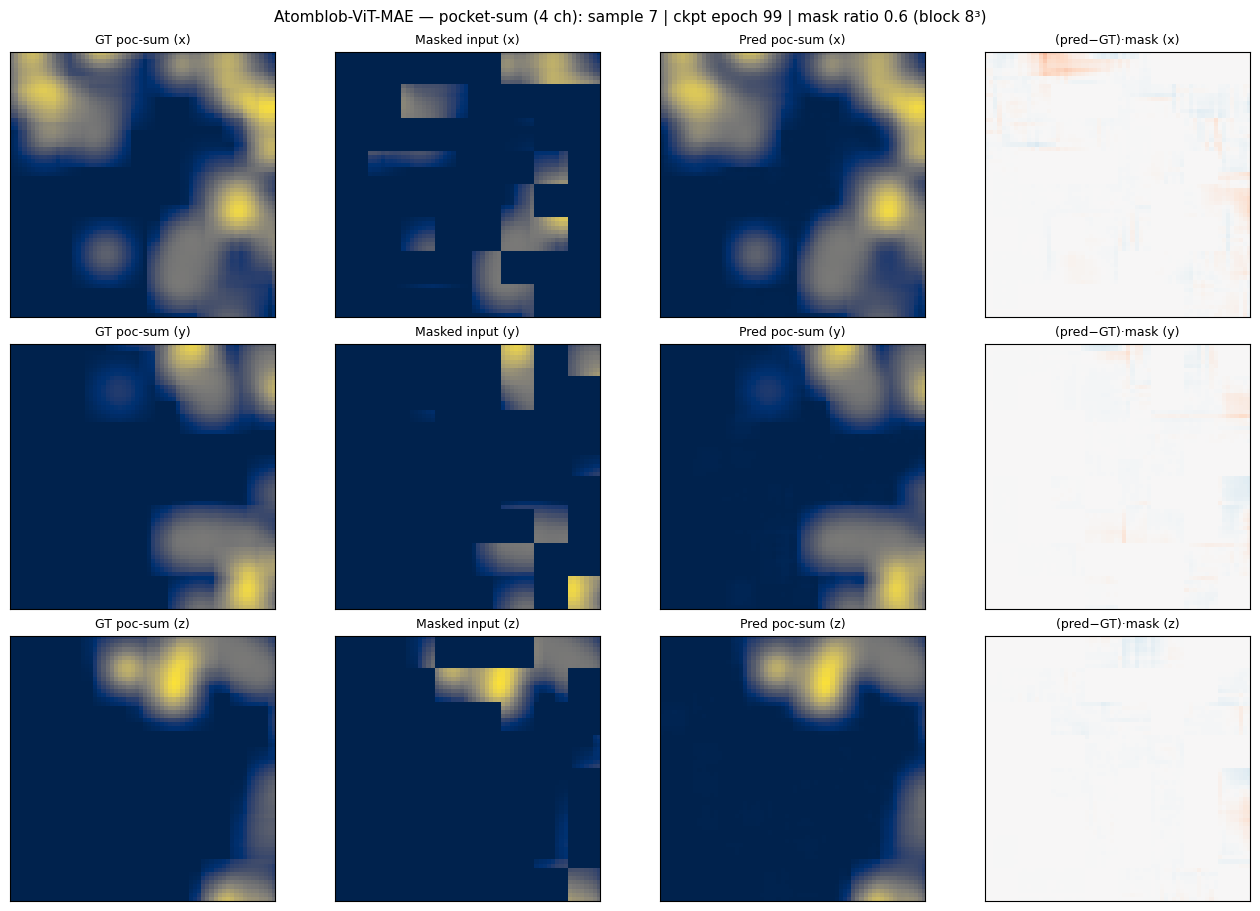

In [9]:
# ── plot 1b: pocket-sum (4 ch) GT | masked | pred | error, for x/y/z planes ───────────
tgt_poc  = x_clean[0, 7:].sum(0)
in_poc   = x_in[0, 7:].sum(0)
pred_poc = out_pretext[0, 7:].sum(0)
err_poc  = (out_pretext[0, 7:] - x_clean[0, 7:]).sum(0) * mask_3d.float()

vmax_poc = max(tgt_poc.max().item(), pred_poc.max().item(), 1e-3)
err_abs_poc = max(err_poc.abs().max().item(), 1e-3)

fig, axes = plt.subplots(3, 4, figsize=(13, 9), constrained_layout=True)
for i, ax_name in enumerate(['x', 'y', 'z']):
    show(axes[i, 0], take_slice(tgt_poc, ax_name, SLICE_OFFSET),
         f'GT poc-sum ({ax_name})',     cmap='cividis', vmin=0,            vmax=vmax_poc)
    show(axes[i, 1], take_slice(in_poc, ax_name, SLICE_OFFSET),
         f'Masked input ({ax_name})',  cmap='cividis', vmin=0,            vmax=vmax_poc)
    show(axes[i, 2], take_slice(pred_poc, ax_name, SLICE_OFFSET),
         f'Pred poc-sum ({ax_name})',  cmap='cividis', vmin=0,            vmax=vmax_poc)
    show(axes[i, 3], take_slice(err_poc, ax_name, SLICE_OFFSET),
         f'(pred−GT)·mask ({ax_name})', cmap='RdBu_r', vmin=-err_abs_poc, vmax=err_abs_poc)
fig.suptitle(
    f"Atomblob-ViT-MAE — pocket-sum (4 ch): sample {SAMPLE_IDX} | ckpt epoch {ckpt.get('epoch')} | "
    f"mask ratio {MASK_RATIO} (block {BLOCK_SIZE}³)",
    fontsize=11,
)
plt.show()

## Plot 2 — per-channel target / predicted / abs-error

All 11 channels on a single slice (`SLICE_AXIS`, `SLICE_OFFSET`). Channel labels come from `voxbind/constants.py::ELEMENTS_HASH_CROSSDOCKED` (ligand uses all 7 element types, pocket uses the first 4).

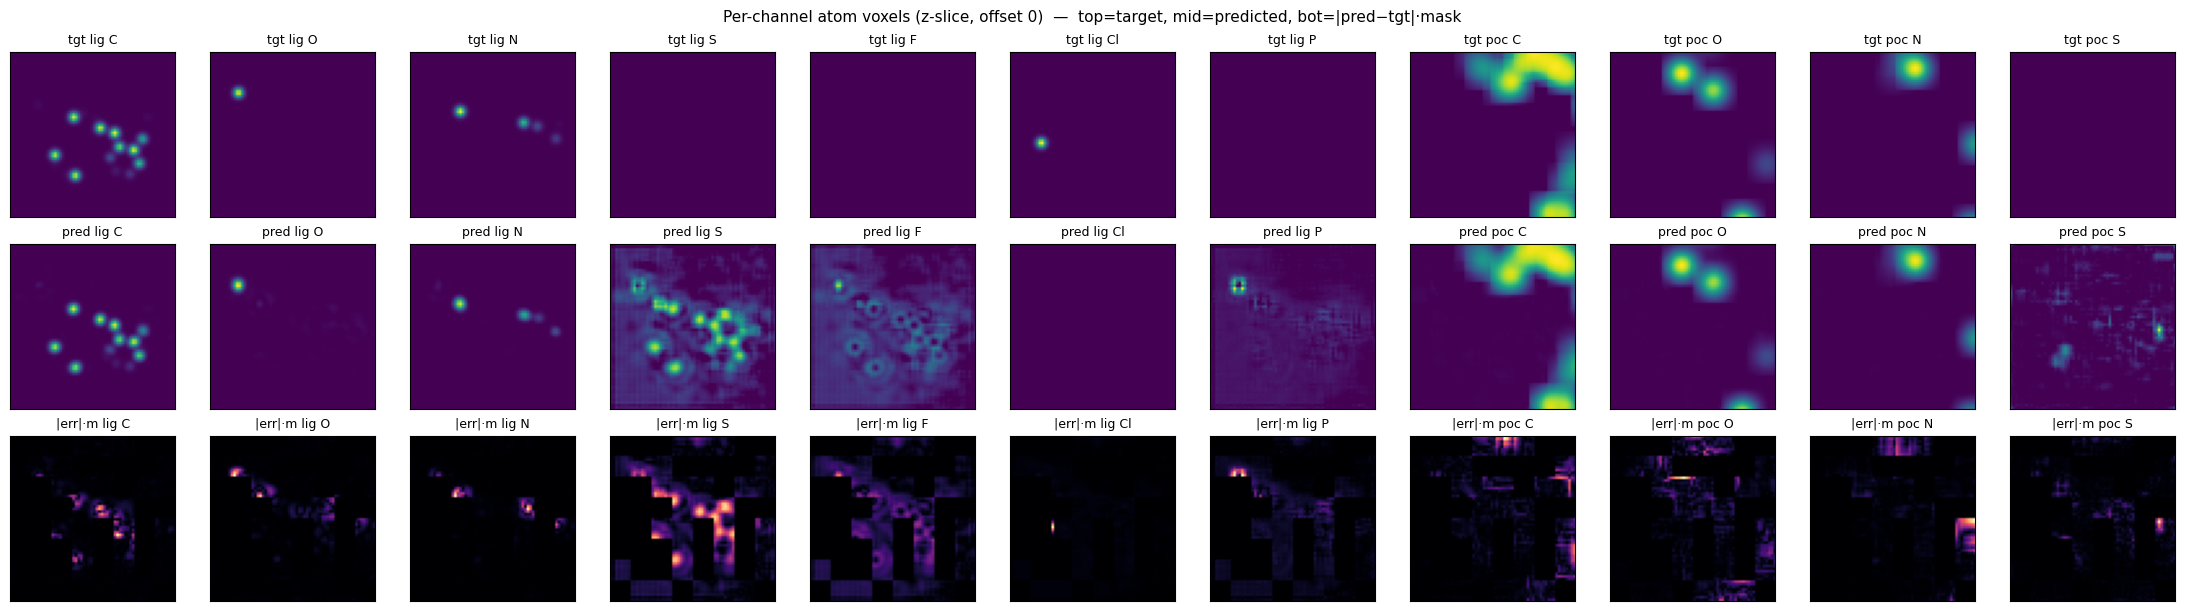

In [10]:
# ── per-channel grid: 3 rows × 11 cols (target / pred / |error|*mask) ────────────────
elem_names = list(ELEMENTS_HASH_CROSSDOCKED.keys())
lig_names = [f'lig {elem_names[i]}' for i in range(7)]
poc_names = [f'poc {elem_names[i]}' for i in range(4)]
chan_names = lig_names + poc_names

fig, axes = plt.subplots(3, 11, figsize=(22, 6.0), constrained_layout=True)
for c in range(11):
    tgt  = take_slice(x_clean[0, c],     SLICE_AXIS, SLICE_OFFSET)
    pred = take_slice(out_pretext[0, c], SLICE_AXIS, SLICE_OFFSET)
    err  = take_slice(
        ((out_pretext[0, c] - x_clean[0, c]).abs() * mask_3d.float()),
        SLICE_AXIS, SLICE_OFFSET,
    )
    vmax = max(float(tgt.max()), float(pred.max()), 1e-3)
    show(axes[0, c], tgt,  f'tgt {chan_names[c]}',  cmap='viridis', vmin=0, vmax=vmax)
    show(axes[1, c], pred, f'pred {chan_names[c]}', cmap='viridis', vmin=0, vmax=vmax)
    show(axes[2, c], err,  f'|err|·m {chan_names[c]}', cmap='magma', vmin=0,
         vmax=max(float(err.max()), 1e-3))
fig.suptitle(
    f'Per-channel atom voxels ({SLICE_AXIS}-slice, offset {SLICE_OFFSET})  —  '
    f'top=target, mid=predicted, bot=|pred−tgt|·mask',
    fontsize=11,
)
plt.show()

## Plot 3 — voxel-value distributions (masked positions only)

Two histograms on masked voxels, separated by source. Atom voxels are sparse and almost-binary (≈ 0 in background, peaks near 1 at atom centers), so we plot the >0.01 tail of the GT distribution against the predicted distribution at those same positions.

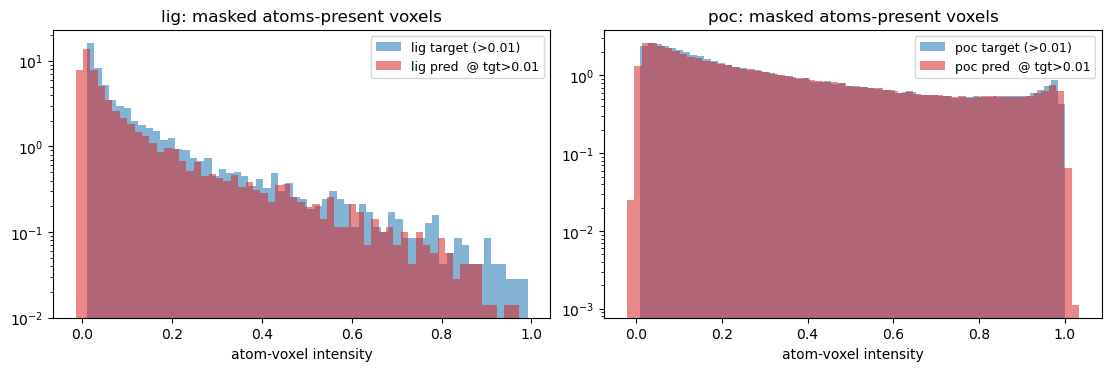

In [11]:
# ── histograms: per-source target vs predicted on masked atoms-present voxels ──────────
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)

m_bool_flat = mask[0, 0].bool().flatten().cpu()
for ax, (name, tgt_full, pred_full) in zip(
    axes,
    [('lig', x_clean[0, :7],  out_pretext[0, :7]),
     ('poc', x_clean[0, 7:],  out_pretext[0, 7:])],
):
    # collapse channel dim to (ch, G³), keep only masked spatial positions
    tgt_flat  = tgt_full.flatten(1).cpu()[:, m_bool_flat].flatten().numpy()
    pred_flat = pred_full.flatten(1).cpu()[:, m_bool_flat].flatten().numpy()
    sel = tgt_flat > 0.01
    ax.hist(tgt_flat[sel],  bins=60, alpha=0.55, color='C0', density=True,
            label=f'{name} target (>0.01)')
    ax.hist(pred_flat[sel], bins=60, alpha=0.55, color='C3', density=True,
            label=f'{name} pred  @ tgt>0.01')
    ax.set_yscale('log')
    ax.set_xlabel('atom-voxel intensity')
    ax.legend(fontsize=9)
    ax.set_title(f'{name}: masked atoms-present voxels')
plt.show()

## Notes

* `SAMPLE_IDX` ∈ [0, 99]. Re-run cells 4–end to swap sample.
* `CKPT_PATH` defaults to the rolling `checkpoint.pth.tar` — point to e.g. `checkpoint_e0020.pth.tar` to inspect earlier epochs.
* `SEED_MASK` matches the density-MAE inspect notebooks (=0) so the same voxel patches are masked across the three input-mode variants for a direct head-to-head.
* The model returns `(out_pretext, a_hat)` with `a_hat is None` because `n_struct_channels=0`. The pretext output is the 11-ch reconstruction of the atom voxels themselves.
* `x_noisy = x_clean` in this variant: `sigma_noise = 0.0` so the only corruption is the block-mask multiplication.

### How atomblob differs from the VoxBind dataset input

Nothing about the voxelization changes — `Voxelizer` is called with the same `num_channels=7` (ligand) and `num_channels=4` (pocket), so the 11-channel tensor here is bit-identical to what VoxBind's downstream pipeline consumes. Channels are **not** collapsed; `n_in_channels=11` means the ViT's patch embed sees all 11 of them. The atomblob-MAE variant only changes what happens *after* voxelization: skip the Gaussian blur, skip noise, hand the raw atom voxels straight to a 60% block mask + 11-channel ViT-MAE.